# %% [markdown]
# # Hadamard DTQW Route Optimization — Corrected Notebook
#
# This notebook follows the corrected research plan exactly:
#
# - **Experiment 0** (discarded): original 2D city-graph DTQW — kept only as a
#   diagnostic in a separate notebook, NOT reproduced here.
# - **Experiment 1**: paper-faithful 1D Hadamard DTQW (STEP 1–3 of the plan).
# - **Experiment 2**: 10-city route optimization built on top of Experiment 1
#   (STEP 4–12 of the plan).
#
# Section headers below are labeled with both the **STEP** number from the
# plan and the **PHASE** number from the original code, so you can trace
# every block back to its justification.

# %% [markdown]
# ## Phase 0 — Imports and global parameters
# (Supports STEP 4 onward: this is shared setup, not part of the 1D walk.)

# %%

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import math

In [ ]:
np.set_printoptions(precision=6, suppress=True)
np.random.seed(42)

n_cities = 10

In [ ]:
x = np.array([
    0.554269387, 0.376125156, 0.051884288, 0.048560340, 0.574909957,
    0.845223483, 0.916561361, 0.063353565, 0.708990050, 0.324740555
])

y = np.array([
    0.180978238, 0.518855489, 0.767196762, 0.819692827, 0.834901769,
    0.178691015, 0.939163958, 0.830678509, 0.257090618, 0.573308569
])
cities = np.column_stack((x, y))

assert len(x) == n_cities
assert len(y) == n_cities

print("Number of cities:", n_cities)
print("Cities shape:", cities.shape)
for i, city in enumerate(cities):
    print(f"City {i}: ({city[0]:.9f}, {city[1]:.9f})")

Number of cities: 10
Cities shape: (10, 2)
City 0: (0.554269387, 0.180978238)
City 1: (0.376125156, 0.518855489)
City 2: (0.051884288, 0.767196762)
City 3: (0.048560340, 0.819692827)
City 4: (0.574909957, 0.834901769)
City 5: (0.845223483, 0.178691015)
City 6: (0.916561361, 0.939163958)
City 7: (0.063353565, 0.830678509)
City 8: (0.708990050, 0.257090618)
City 9: (0.324740555, 0.573308569)


# # STEP 1 — Paper-faithful 1D Hadamard walk
# (Phases 7–9 of the original code.)
#
# Forget the cities temporarily. Use positions `x = 0..N-1` and a two-state
# coin `|0>, |1>` with the standard Hadamard coin, periodic boundary shift:
#
#     H = (1/sqrt2) [[1, 1], [1, -1]]
#     S|x>|0> -> |x+1>|0>
#     S|x>|1> -> |x-1>|1>
#     W = S (I ⊗ H)

In [ ]:
H = np.array([
    [1, 1],
    [1, -1]
], dtype=complex) / np.sqrt(2)

print("Hadamard matrix:")
print(H)

identity_coin = np.eye(2)
print("\nH dagger H = I:", np.allclose(H.conj().T @ H, identity_coin))

Hadamard matrix:
[[ 0.707107+0.j  0.707107+0.j]
 [ 0.707107+0.j -0.707107+0.j]]

H dagger H = I: True


In [ ]:
# ## Phase 8 — 1D periodic Hadamard walk operators

# %%
def hadamard_coin_state(state, num_positions):
    state = state.reshape(num_positions, 2)
    new_state = np.zeros_like(state)
    for position in range(num_positions):
        coin_state = state[position]
        new_state[position] = H @ coin_state
    return new_state.reshape(-1)

In [ ]:
def conditional_shift(state, num_positions):
    state = state.reshape(num_positions, 2)
    shifted = np.zeros_like(state)

    for position in range(num_positions):
        # Coin |0> -> move right
        right_position = (position + 1) % num_positions
        shifted[right_position, 0] += state[position, 0]

        # Coin |1> -> move left
        left_position = (position - 1) % num_positions
        shifted[left_position, 1] += state[position, 1]

    return shifted.reshape(-1)

In [ ]:
def quantum_walk_step(state, num_positions):
    state_after_coin = hadamard_coin_state(state, num_positions)
    state_after_shift = conditional_shift(state_after_coin, num_positions)
    return state_after_shift


#---
## STEP 2 — Verify NumPy mathematically
# (Phase 9–10 of the original code.)

# Check unitarity of H, unitarity of S, unitarity of W, and probability
# normalization sum_x P(x) = 1 across the evolution.


# ## Phase 9 — Run and verify the 1D walk

In [ ]:
num_positions = 11
num_steps = 12

state = np.zeros(num_positions * 2, dtype=complex)

# Start at position 0, coin starts in |0>
state[0 * 2 + 0] = 1.0

print("Initial norm:", np.linalg.norm(state))

for step in range(num_steps):
    state = quantum_walk_step(state, num_positions)
    norm = np.linalg.norm(state)
    probability = np.sum(np.abs(state) ** 2)
    print(f"Step {step + 1:2d}: norm = {norm:.12f}, probability = {probability:.12f}")

Initial norm: 1.0
Step  1: norm = 1.000000000000, probability = 1.000000000000
Step  2: norm = 1.000000000000, probability = 1.000000000000
Step  3: norm = 1.000000000000, probability = 1.000000000000
Step  4: norm = 1.000000000000, probability = 1.000000000000
Step  5: norm = 1.000000000000, probability = 1.000000000000
Step  6: norm = 1.000000000000, probability = 1.000000000000
Step  7: norm = 1.000000000000, probability = 1.000000000000
Step  8: norm = 1.000000000000, probability = 1.000000000000
Step  9: norm = 1.000000000000, probability = 1.000000000000
Step 10: norm = 1.000000000000, probability = 1.000000000000
Step 11: norm = 1.000000000000, probability = 1.000000000000
Step 12: norm = 1.000000000000, probability = 1.000000000000


# %% [markdown]
# ## Phase 10 — Position probability distribution

In [ ]:
def position_probabilities(state, num_positions):
    state = state.reshape(num_positions, 2)
    probabilities = np.sum(np.abs(state) ** 2, axis=1)
    return probabilities


probabilities = position_probabilities(state, num_positions)

print("\nFinal probability distribution:")
for position, probability in enumerate(probabilities):
    print(f"Position {position}: {probability:.8f}")

print("\nProbability sum:", np.sum(probabilities))


Final probability distribution:
Position 0: 0.04882812
Position 1: 0.02075195
Position 2: 0.05664062
Position 3: 0.10009766
Position 4: 0.12426758
Position 5: 0.01806641
Position 6: 0.19580078
Position 7: 0.03833008
Position 8: 0.31884766
Position 9: 0.04882812
Position 10: 0.02954102

Probability sum: 0.9999999999999982


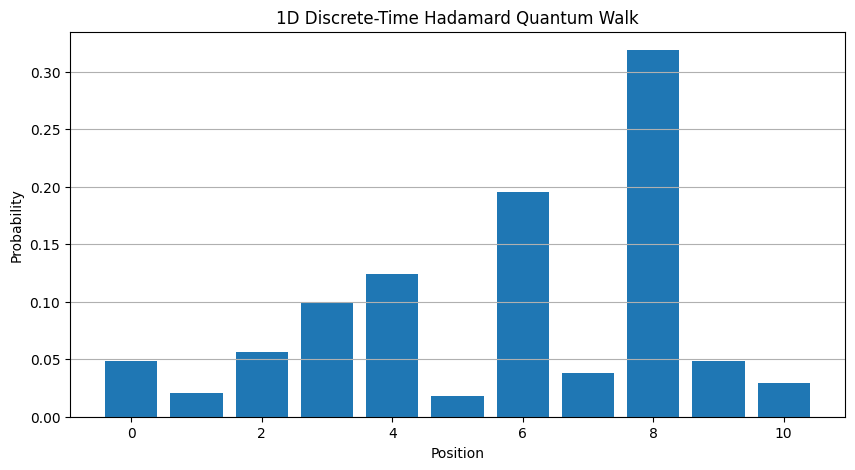

In [ ]:
# %% [markdown]
# ## Phase 11 — Plot the 1D DTQW

# %%
plt.figure(figsize=(10, 5))
plt.bar(np.arange(num_positions), probabilities)
plt.xlabel("Position")
plt.ylabel("Probability")
plt.title("1D Discrete-Time Hadamard Quantum Walk")
plt.grid(axis="y")
plt.show()


In [ ]:
%%capture
!pip install qiskit
!pip install qiskit-aer

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
# If qiskit_aer is unavailable in your environment, install/update Aer.
# Do NOT fall back to the deprecated `from qiskit import Aer, execute`.

# ## Phase 29 — Qiskit Hadamard coin

qc = QuantumCircuit(1)
qc.h(0)
print(qc)

   ┌───┐
q: ┤ H ├
   └───┘


In [ ]:
# ## Phase 30 — Qiskit statevector verification

from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)
statevector = Statevector.from_instruction(qc)
print(statevector)
# Expected: (|0> + |1>) / sqrt(2)

Statevector([0.707107+0.j, 0.707107+0.j],
            dims=(2,))


In [ ]:
numpy_hadamard_state = H @ np.array([1, 0], dtype=complex)
qiskit_hadamard_state = np.asarray(statevector.data)

print("NumPy:")
print(numpy_hadamard_state)
print("\nQiskit:")
print(qiskit_hadamard_state)

print(
    "\nEquivalent up to global phase:",
    np.allclose(np.abs(numpy_hadamard_state), np.abs(qiskit_hadamard_state))
)

NumPy:
[0.707107+0.j 0.707107+0.j]

Qiskit:
[0.707107+0.j 0.707107+0.j]

Equivalent up to global phase: True


In [ ]:
# ## Phase 32 — Small Qiskit coined walk (demonstration only)
#
# Full route space would require ceil(log2(362880)) = 19 position qubits +
# 1 coin qubit = 20 qubits, plus an arbitrary route-cost phase oracle. That
# is out of scope here; this block only shows the coin portion on a small
# 4-position toy system to keep the NumPy vs Qiskit comparison grounded.

# %%
num_positions_q = 4
position_qubits = 2
coin_qubit = 2

qc = QuantumCircuit(position_qubits + 1)

# Initial position = 0, coin = |0>
qc.h(coin_qubit)
print(qc)

          
q_0: ─────
          
q_1: ─────
     ┌───┐
q_2: ┤ H ├
     └───┘


In [ ]:
def distance(city_a, city_b):
    return np.linalg.norm(city_a - city_b)


def build_distance_matrix(cities):
    n = len(cities)
    distance_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = distance(cities[i], cities[j])
    return distance_matrix


distance_matrix = build_distance_matrix(cities)

print("\nDistance matrix:")
print(distance_matrix)
print("\nDistance matrix symmetric:", np.allclose(distance_matrix, distance_matrix.T))
print("Diagonal zero:", np.allclose(np.diag(distance_matrix), 0.0))


Distance matrix:
[[0.       0.381964 0.772038 0.814677 0.654249 0.290963 0.840298 0.814315
  0.172428 0.45454 ]
 [0.381964 0.       0.408418 0.444749 0.373364 0.579452 0.684639 0.441656
  0.423462 0.07487 ]
 [0.772038 0.408418 0.       0.052601 0.52739  0.987788 0.881612 0.06451
  0.831863 0.334729]
 [0.814677 0.444749 0.052601 0.       0.526569 1.022524 0.876184 0.018426
  0.867576 0.370109]
 [0.654249 0.373364 0.52739  0.526569 0.       0.709706 0.357206 0.511574
  0.593164 0.361961]
 [0.290963 0.579452 0.987788 1.022524 0.709706 0.       0.763812 1.018041
  0.157182 0.653166]
 [0.840298 0.684639 0.881612 0.876184 0.357206 0.763812 0.       0.860077
  0.712959 0.695774]
 [0.814315 0.441656 0.06451  0.018426 0.511574 1.018041 0.860077 0.
  0.863626 0.366828]
 [0.172428 0.423462 0.831863 0.867576 0.593164 0.157182 0.712959 0.863626
  0.       0.497636]
 [0.45454  0.07487  0.334729 0.370109 0.361961 0.653166 0.695774 0.366828
  0.497636 0.      ]]

Distance matrix symmetric: True
Diago

In [ ]:
# ## Phase 2 — Route representation and route cost

# %%
def route_distance(route, distance_matrix):
    total_distance = 0.0
    for k in range(len(route) - 1):
        total_distance += distance_matrix[route[k], route[k + 1]]
    total_distance += distance_matrix[route[-1], route[0]]  # close the loop
    return total_distance


test_route = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
test_cost = route_distance(test_route, distance_matrix)

print("Test route:", test_route)
print("Test route distance:", test_cost)

Test route: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
Test route distance: 5.51894861596255


In [ ]:
# # STEP 5 — Build the classical route space
# (Phase 3 of the original code.)
#
# route j <-> permutation R_j, with City 0 fixed as start to remove
# rotational duplicates. There are 9! = 362,880 routes.

# %%
cities_to_visit = tuple(range(1, n_cities))

routes = []
for permutation_part in permutations(cities_to_visit):
    route = (0,) + permutation_part
    routes.append(route)

routes = np.array(routes, dtype=np.int16)
num_routes = len(routes)

print("Number of routes:", num_routes)

expected_routes = math.factorial(n_cities - 1)
print("Expected:", expected_routes)
assert num_routes == expected_routes

Number of routes: 362880
Expected: 362880


In [ ]:
# ## Phase 4 — Calculate every route cost

# %%
route_costs = np.zeros(num_routes)

for route_index in range(num_routes):
    route = routes[route_index]
    route_costs[route_index] = route_distance(route, distance_matrix)

print("Number of route costs:", len(route_costs))
print("Minimum route cost found:", np.min(route_costs))
print("Maximum route cost:", np.max(route_costs))

Number of route costs: 362880
Minimum route cost found: 2.8247914720764427
Maximum route cost: 7.3614890967099855


In [ ]:
best_route_index = np.argmin(route_costs)
best_classical_route = tuple(routes[best_route_index])
best_classical_distance = route_costs[best_route_index]

print("\n========== CLASSICAL OPTIMUM ==========")
print("Best route:")
print(" -> ".join(map(str, best_classical_route)) + " -> 0")
print("Best distance:", best_classical_distance)


========== CLASSICAL OPTIMUM ==========
Best route:
0 -> 8 -> 5 -> 6 -> 4 -> 7 -> 3 -> 2 -> 9 -> 1 -> 0
Best distance: 2.8247914720764427


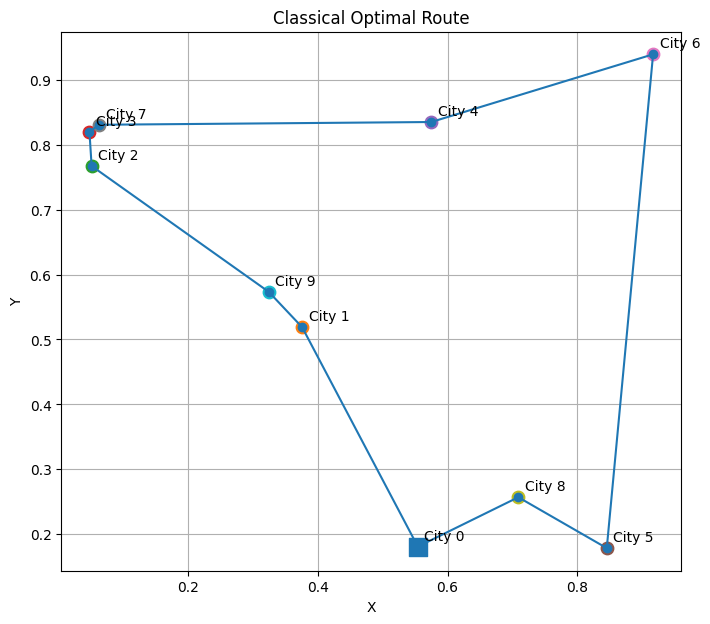

In [ ]:
def plot_route(route, cities, title):
    plt.figure(figsize=(8, 7))
    closed_route = list(route) + [route[0]]
    route_x = [cities[i][0] for i in closed_route]
    route_y = [cities[i][1] for i in closed_route]

    plt.plot(route_x, route_y, marker="o")

    for i in range(len(cities)):
        if i == 0:
            plt.scatter(cities[i][0], cities[i][1], s=150, marker="s")
        else:
            plt.scatter(cities[i][0], cities[i][1], s=80)
        plt.text(cities[i][0] + 0.01, cities[i][1] + 0.01, f"City {i}")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.axis("equal")
    plt.show()


plot_route(best_classical_route, cities, "Classical Optimal Route")

In [ ]:
# ---
# # STEP 7 — Introduce the Frontiers-style quality phase
# (Phase 14 of the original code.)
#
# Q_j = L(R_j), U_Q(gamma) = exp(-i * gamma * Q). This is where route
# distance actually enters the quantum algorithm.

route_space_size = num_routes
route_state_size = route_space_size * 2

print("Route states:", route_space_size)
print("Coin states: 2")
print("Total amplitudes:", route_state_size)

Route states: 362880
Coin states: 2
Total amplitudes: 725760


In [ ]:
# ## Phase 13 — Initial uniform route superposition
#
# psi_0 = (1/sqrt(M)) * sum_j |j>|0>

# %%
route_state = np.zeros(route_state_size, dtype=complex)
amplitude = 1.0 / np.sqrt(route_space_size)

for route_index in range(route_space_size):
    route_state[route_index * 2 + 0] = amplitude

print("Initial norm:", np.linalg.norm(route_state))
print("Initial probability:", np.sum(np.abs(route_state) ** 2))

Initial norm: 1.0000000000008074
Initial probability: 1.0000000000000013


In [ ]:
# ## Phase 14 — Route quality / cost phase operator

# %%
def apply_cost_phase(state, route_costs, gamma):
    state = state.copy()
    phase = np.exp(-1j * gamma * route_costs)
    # Same phase applied to both coin components
    state[0::2] *= phase
    state[1::2] *= phase
    return state

In [ ]:
def apply_route_coin(state, route_space_size):
    state = state.reshape(route_space_size, 2)
    new_state = np.zeros_like(state)
    for route_index in range(route_space_size):
        new_state[route_index] = H @ state[route_index]
    return new_state.reshape(-1)

In [ ]:
# Vectorized fast version (same math, much faster for M = 362,880)
def apply_route_coin_fast(state, route_space_size):
    state = state.reshape(route_space_size, 2)
    new_state = np.empty_like(state)
    new_state[:, 0] = (state[:, 0] + state[:, 1]) / np.sqrt(2)
    new_state[:, 1] = (state[:, 0] - state[:, 1]) / np.sqrt(2)
    return new_state.reshape(-1)

In [ ]:
def route_conditional_shift(state, route_space_size):
    state = state.reshape(route_space_size, 2)
    shifted = np.zeros_like(state)

    # Coin |0> -> j + 1
    shifted[:, 0] = np.roll(state[:, 0], 1)
    # Coin |1> -> j - 1
    shifted[:, 1] = np.roll(state[:, 1], -1)

    return shifted.reshape(-1)

In [ ]:
# ## Phase 17 — Complete route-space DTQW step: W = S (I ⊗ H)

# %%
def route_walk_step(state, route_space_size):
    state = apply_route_coin_fast(state, route_space_size)
    state = route_conditional_shift(state, route_space_size)
    return state

In [ ]:
# # STEP 9 — Hybrid algorithm
# (Phases 18–19 of the original code.)
#
#     psi_{k+1} = W(tau_k) U_Q(gamma_k) psi_k

# ## Phase 18 — Hybrid cost-phase + Hadamard walk step

# %%
def hybrid_step(state, route_costs, gamma, route_space_size):
    # 1. Quality / cost phase
    state = apply_cost_phase(state, route_costs, gamma)
    # 2. Hadamard DTQW
    state = route_walk_step(state, route_space_size)
    return state

In [ ]:
gamma = 0.01
num_steps = 3

state = route_state.copy()

for step in range(num_steps):
    state = hybrid_step(state, route_costs, gamma, route_space_size)
    probability = np.sum(np.abs(state) ** 2)
    norm = np.linalg.norm(state)
    print(f"Step {step + 1}: norm = {norm:.12f}, probability = {probability:.12f}")

Step 1: norm = 1.000000000000, probability = 1.000000000000
Step 2: norm = 1.000000000000, probability = 1.000000000000
Step 3: norm = 1.000000000000, probability = 1.000000000000


In [ ]:
# # STEP 10 — Measurement
# (Phases 20–21 of the original code.)
#
# P_j = |a_j|^2 summed over coin states, then decode j* -> R_j*, and
# compute L(R_j*).

# ## Phase 20 — Route probabilities

# %%
def route_probabilities(state, route_space_size):
    state = state.reshape(route_space_size, 2)
    probabilities = np.sum(np.abs(state) ** 2, axis=1)
    return probabilities


route_prob = route_probabilities(state, route_space_size)

print("Probability sum:", np.sum(route_prob))
print("Most probable route index:", np.argmax(route_prob))

Probability sum: 0.9999999999999996
Most probable route index: 286656


In [ ]:
def decode_route(route_index, routes):
    return tuple(routes[route_index])


most_probable_index = np.argmax(route_prob)
quantum_route = decode_route(most_probable_index, routes)
quantum_distance = route_distance(quantum_route, distance_matrix)

print("\n========== QUANTUM RESULT ==========")
print("Route:")
print(" -> ".join(map(str, quantum_route)) + " -> 0")
print("Distance:", quantum_distance)


========== QUANTUM RESULT ==========
Route:
0 -> 8 -> 1 -> 9 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 3.928809120641987


In [ ]:
gap_percent = (
    (quantum_distance - best_classical_distance) / best_classical_distance
) * 100

print("\n========== COMPARISON ==========")
print("Classical distance:", best_classical_distance)
print("Quantum-walk distance:", quantum_distance)
print("Gap:", gap_percent, "%")

if quantum_distance == best_classical_distance:
    print("Quantum result matches the classical optimum.")
elif quantum_distance > best_classical_distance:
    print("Quantum result is above the classical optimum.")
else:
    # Should never happen if the classical enumeration is correct
    print("Unexpected: quantum distance is below the exact classical optimum.")


========== COMPARISON ==========
Classical distance: 2.8247914720764427
Quantum-walk distance: 3.928809120641987
Gap: 39.08315567640839 %
Quantum result is above the classical optimum.


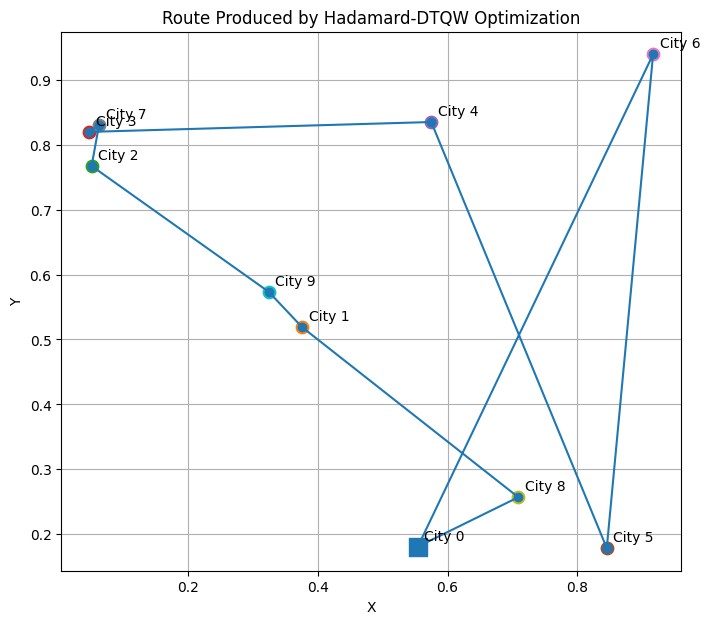

In [ ]:
plot_route(quantum_route, cities, "Route Produced by Hadamard-DTQW Optimization")

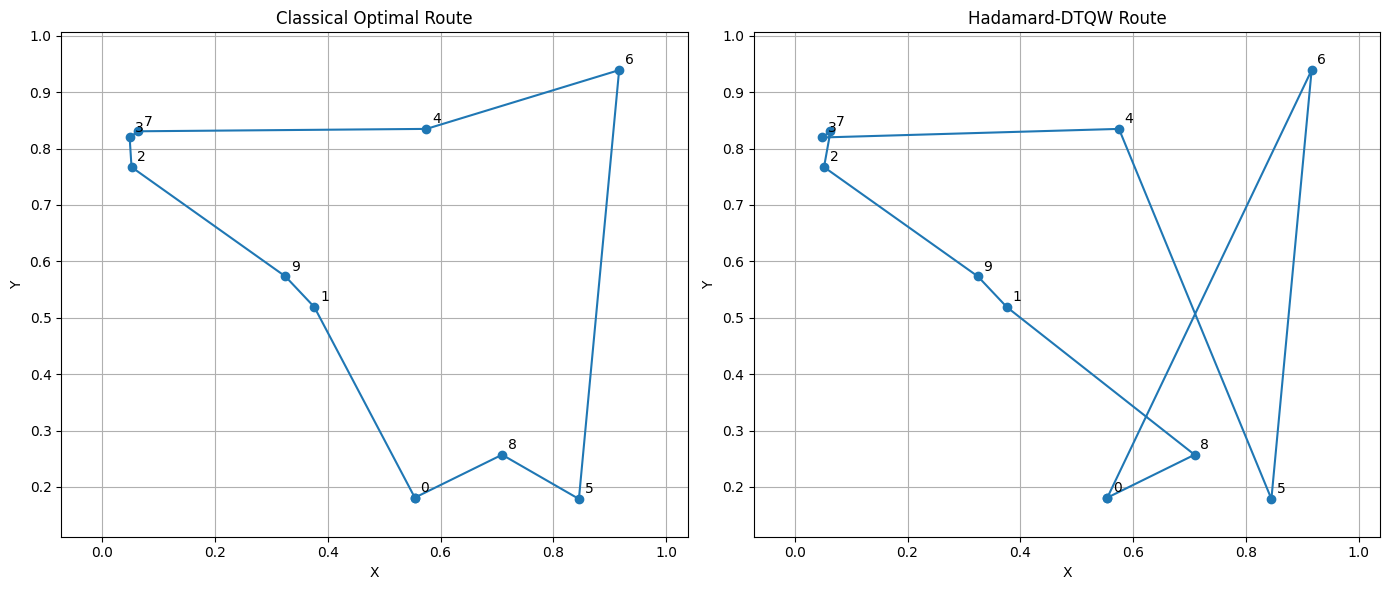

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classical
closed_classical = list(best_classical_route) + [best_classical_route[0]]
classical_x = [cities[i][0] for i in closed_classical]
classical_y = [cities[i][1] for i in closed_classical]

axes[0].plot(classical_x, classical_y, marker="o")
for i in range(n_cities):
    axes[0].text(cities[i][0] + 0.01, cities[i][1] + 0.01, str(i))
axes[0].set_title("Classical Optimal Route")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid(True)
axes[0].axis("equal")

# Quantum
closed_quantum = list(quantum_route) + [quantum_route[0]]
quantum_x = [cities[i][0] for i in closed_quantum]
quantum_y = [cities[i][1] for i in closed_quantum]

axes[1].plot(quantum_x, quantum_y, marker="o")
for i in range(n_cities):
    axes[1].text(cities[i][0] + 0.01, cities[i][1] + 0.01, str(i))
axes[1].set_title("Hadamard-DTQW Route")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].grid(True)
axes[1].axis("equal")

plt.tight_layout()
plt.show()

In [ ]:
num_top_routes = 10
top_indices = np.argsort(route_prob)[-num_top_routes:][::-1]

print("\n========== TOP QUANTUM ROUTES ==========")
for rank, index in enumerate(top_indices, start=1):
    route = tuple(routes[index])
    print(f"\nRank {rank}")
    print("Route:", " -> ".join(map(str, route)) + " -> 0")
    print("Distance:", route_costs[index])
    print("Probability:", route_prob[index])


========== TOP QUANTUM ROUTES ==========

Rank 1
Route: 0 -> 8 -> 1 -> 9 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 3.928809120641987
Probability: 2.757178552792555e-06

Rank 2
Route: 0 -> 1 -> 8 -> 9 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 4.561110415865678
Probability: 2.757178552792554e-06

Rank 3
Route: 0 -> 8 -> 9 -> 1 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 4.076673028717307
Probability: 2.7571785527925532e-06

Rank 4
Route: 0 -> 9 -> 8 -> 1 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 4.707376313751714
Probability: 2.7571785527925532e-06

Rank 5
Route: 0 -> 9 -> 1 -> 8 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 4.70805522506281
Probability: 2.7571785527925532e-06

Rank 6
Route: 0 -> 1 -> 9 -> 8 -> 2 -> 7 -> 3 -> 4 -> 5 -> 6 -> 0
Distance: 4.709653235252095
Probability: 2.7571785527925532e-06

Rank 7
Route: 0 -> 9 -> 1 -> 8 -> 3 -> 7 -> 2 -> 4 -> 5 -> 6 -> 0
Distance: 4.744588728739083
Probability: 2.757121812707362e-06

Rank 8
Route: 0 -> 8 -> 9 -> 1 -> 3 -> 7 -> 

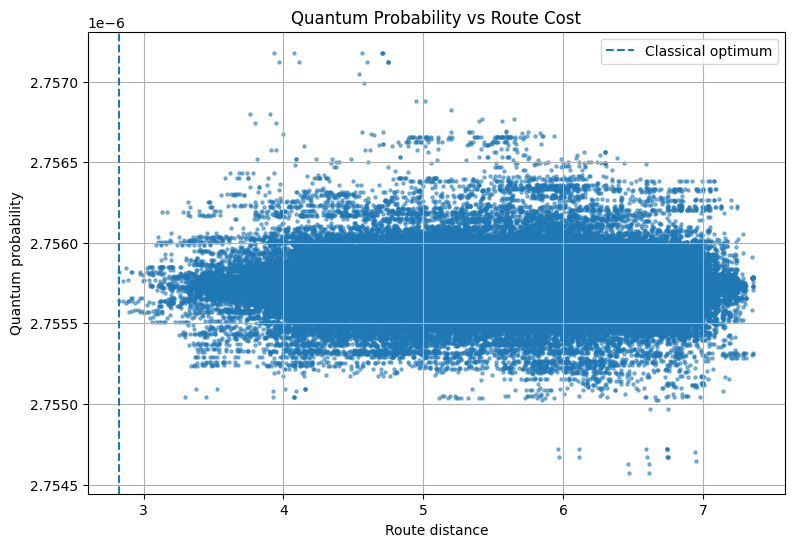

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(route_costs, route_prob, s=5, alpha=0.5)
plt.axvline(best_classical_distance, linestyle="--", label="Classical optimum")
plt.xlabel("Route distance")
plt.ylabel("Quantum probability")
plt.title("Quantum Probability vs Route Cost")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ## Phase 27 — Probability of the classical optimum
#
# If this probability is high relative to a uniform 1/M baseline, that's
# evidence the hybrid evolution favors the optimal route. If it's tiny
# (comparable to 1/M), the algorithm/parameters aren't working well yet.

# %%
optimal_probability = route_prob[best_route_index]

print("Classical optimum route:", best_classical_route)
print("Probability of classical optimum:", optimal_probability)
print("Uniform baseline (1/M):", 1.0 / route_space_size)


Classical optimum route: (np.int16(0), np.int16(8), np.int16(5), np.int16(6), np.int16(4), np.int16(7), np.int16(3), np.int16(2), np.int16(9), np.int16(1))
Probability of classical optimum: 2.7556380962452754e-06
Uniform baseline (1/M): 2.7557319223985893e-06


In [ ]:
def perm_rank_vectorized(tail):
    """
    tail: (M, k) int array, each row a permutation of the same k-element
    alphabet, in the row order used to build the `routes` array (i.e. the
    order produced by itertools.permutations).

    Returns: (M,) int array of ranks in [0, k!-1], via the Lehmer code:
        L_i = #{ j > i : tail[j] < tail[i] }
        rank = sum_i L_i * (k-1-i)!
    This holds for ANY alphabet (not just contiguous integers), since at
    step i the "remaining" elements are exactly tail[i:], by construction.
    """
    M, k = tail.shape

    less = tail[:, None, :] < tail[:, :, None]   # less[:, i, j] = tail[j] < tail[i]
    upper = np.triu(np.ones((k, k), dtype=bool), k=1)  # keep only j > i
    L = np.sum(less & upper[None, :, :], axis=2)        # shape (M, k)

    factorials = np.array([math.factorial(k - 1 - i) for i in range(k)])
    rank = (L * factorials[None, :]).sum(axis=1)

    return rank

In [ ]:
# Sanity check against the existing `routes` array from Phase 3/STEP 5
_check_tail = routes[:5, 1:]
_check_rank = perm_rank_vectorized(_check_tail)
print("Rank sanity check (should be 0,1,2,3,4):", _check_rank)
assert np.array_equal(_check_rank, np.arange(5))

Rank sanity check (should be 0,1,2,3,4): [0 1 2 3 4]


In [ ]:
# ## Step B — 2-opt move list and vectorized neighbor-index table
#
# Computed ONCE (per move type, vectorized across all M routes) via the
# rank formula above — this is the "on-the-fly" generation: neighbor
# indices are derived algorithmically, not read from a stored graph file.

# %%
MOVES = [(i, j) for i in range(1, n_cities - 1) for j in range(i + 1, n_cities)]
degree = len(MOVES)

print("Number of 2-opt moves per route (coin dimension):", degree)
assert degree == math.comb(n_cities - 1, 2)


def apply_2opt_move_vectorized(routes_array, i, j):
    new_routes = routes_array.copy()
    new_routes[:, i:j + 1] = routes_array[:, i:j + 1][:, ::-1]
    return new_routes


neighbor_index = np.zeros((num_routes, degree), dtype=np.int64)

for move_idx, (i, j) in enumerate(MOVES):
    neighbor_routes = apply_2opt_move_vectorized(routes, i, j)
    tail = neighbor_routes[:, 1:]
    neighbor_index[:, move_idx] = perm_rank_vectorized(tail)

print("neighbor_index shape:", neighbor_index.shape)

Number of 2-opt moves per route (coin dimension): 36
neighbor_index shape: (362880, 36)


In [ ]:
# Involution check: applying the SAME move again must return to the
# original route index for every route (this is what makes the shift
# unitary by construction).
_back = neighbor_index[neighbor_index[:, 0], 0]
assert np.array_equal(_back, np.arange(num_routes)), "2-opt move is not self-inverse as expected"
print("Involution check passed: reversing the same segment twice returns the original route.")

Involution check passed: reversing the same segment twice returns the original route.


In [ ]:
# ## Step C — Grover diffusion coin (generalized Hadamard for d-regular graphs)

# %%
J = np.ones((degree, degree))
C_coin = (2.0 / degree) * J - np.eye(degree)

print("Coin unitary check (C^dagger C = I):",
      np.allclose(C_coin.conj().T @ C_coin, np.eye(degree)))


def apply_route_coin_2opt(state):
    # state shape (M, degree); C_coin is symmetric, so state @ C_coin
    # applies C to each route's local coin vector.
    return state @ C_coin

Coin unitary check (C^dagger C = I): True


In [ ]:
# ## Step D — 2-opt shift and cost-phase operators

# %%
def route_2opt_shift(state, neighbor_index):
    new_state = np.zeros_like(state)
    for m in range(neighbor_index.shape[1]):
        new_state[neighbor_index[:, m], m] = state[:, m]
    return new_state


def apply_cost_phase_2opt(state, route_costs, gamma):
    phase = np.exp(-1j * gamma * route_costs)
    return state * phase[:, None]


def hybrid_step_2opt(state, route_costs, gamma, neighbor_index):
    state = apply_cost_phase_2opt(state, route_costs, gamma)
    state = apply_route_coin_2opt(state)
    state = route_2opt_shift(state, neighbor_index)
    return state

In [ ]:
# Start with a few steps first, exactly as with the ring version — this is
# an expensive state to evolve, so verify norm/probability stay at 1
# before scaling up steps or sweeping gamma.

# %%
gamma_2opt = 0.01
num_steps_2opt = 3

state_2opt = np.full((num_routes, degree), 1.0 / np.sqrt(num_routes * degree), dtype=complex)

print("Initial norm:", np.linalg.norm(state_2opt))

for step in range(num_steps_2opt):
    state_2opt = hybrid_step_2opt(state_2opt, route_costs, gamma_2opt, neighbor_index)
    norm = np.linalg.norm(state_2opt)
    probability = np.sum(np.abs(state_2opt) ** 2)
    print(f"Step {step + 1}: norm = {norm:.12f}, probability = {probability:.12f}")

Initial norm: 0.9999999999784346
Step 1: norm = 1.000000000000, probability = 1.000000000000
Step 2: norm = 1.000000000000, probability = 1.000000000000
Step 3: norm = 1.000000000000, probability = 1.000000000000


Probability sum: 0.9999999999999993

========== EXPERIMENT 3 (2-opt walk) RESULT ==========
Route: 0 -> 1 -> 9 -> 2 -> 3 -> 7 -> 4 -> 6 -> 5 -> 8 -> 0
Distance: 2.824791472076443
Classical optimum distance: 2.8247914720764427
Gap: 1.5721132488538075e-14 %
Probability assigned to the TRUE classical optimum route: 2.7611136986204157e-06
Uniform baseline (1/M) for comparison: 2.7557319223985893e-06
Above baseline: some evidence the walk is biasing toward the optimum.


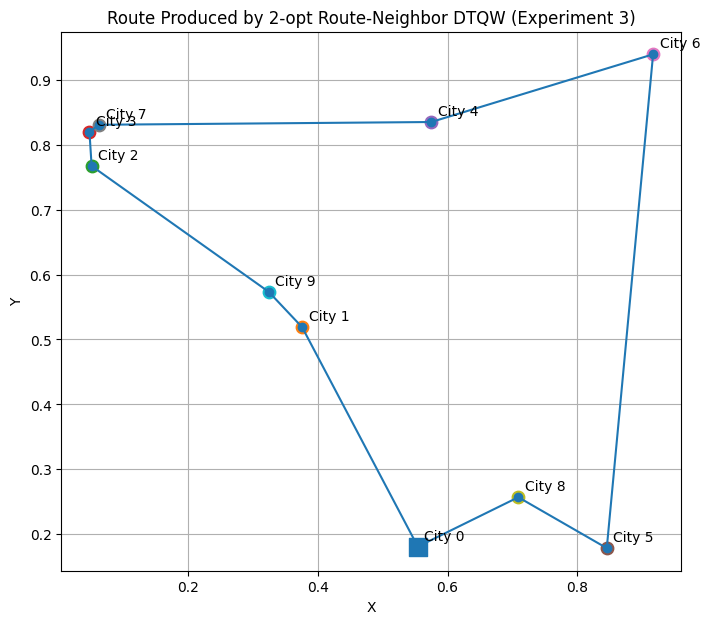

In [ ]:
# ## Step F — Measurement, decode, and compare against the classical optimum

# %%
route_prob_2opt = np.sum(np.abs(state_2opt) ** 2, axis=1)

print("Probability sum:", np.sum(route_prob_2opt))

best_quantum_index_2opt = np.argmax(route_prob_2opt)
quantum_route_2opt = decode_route(best_quantum_index_2opt, routes)
quantum_distance_2opt = route_distance(quantum_route_2opt, distance_matrix)

optimal_probability_2opt = route_prob_2opt[best_route_index]
uniform_baseline = 1.0 / num_routes

print("\n========== EXPERIMENT 3 (2-opt walk) RESULT ==========")
print("Route:", " -> ".join(map(str, quantum_route_2opt)) + " -> 0")
print("Distance:", quantum_distance_2opt)
print("Classical optimum distance:", best_classical_distance)
print("Gap:", (quantum_distance_2opt - best_classical_distance) / best_classical_distance * 100, "%")
print("Probability assigned to the TRUE classical optimum route:", optimal_probability_2opt)
print("Uniform baseline (1/M) for comparison:", uniform_baseline)

if optimal_probability_2opt > uniform_baseline:
    print("Above baseline: some evidence the walk is biasing toward the optimum.")
else:
    print("At/below baseline: no evidence yet — try more steps or sweep gamma before concluding.")

plot_route(quantum_route_2opt, cities, "Route Produced by 2-opt Route-Neighbor DTQW (Experiment 3)")